# Interactive follow-up: Quantum circuits

This notebook is a guided follow-up to the chapter section **2.1.2 Quantum circuits**.

It is meant to make the main ideas interactive:

- quantum circuits as sequences of operations,
- wires as qubit systems that carry quantum states,
- gates as physical operations that change states,
- circuit order versus matrix multiplication order,
- Bell-state construction,
- inverse or “mirror” circuits,
- CNOT, CZ, SWAP, Toffoli, and CCZ,
- Pauli operators and Clifford gates,
- \(T\) gates and phase,
- simple phase-polynomial intuition,
- uniformly-controlled gates.

At the end, there are **7 simple follow-up exercises**.

## 0. Setup

Run this cell first. It defines the states, gates, helper functions, and simple visualization tools.

This notebook only uses `numpy`, `matplotlib`, and optionally `ipywidgets`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    import ipywidgets as widgets
    from ipywidgets import interact
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not available. Interactive sliders/dropdowns will be disabled.")

np.set_printoptions(precision=3, suppress=True)

# Basic one-qubit states
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)
ket_plus = (ket0 + ket1) / np.sqrt(2)
ket_minus = (ket0 - ket1) / np.sqrt(2)

# One-qubit gates
I = np.eye(2, dtype=complex)

X = np.array([[0, 1],
              [1, 0]], dtype=complex)

Y = np.array([[0, -1j],
              [1j, 0]], dtype=complex)

Z = np.array([[1, 0],
              [0, -1]], dtype=complex)

H = (1 / np.sqrt(2)) * np.array([[1, 1],
                                  [1, -1]], dtype=complex)

S = np.array([[1, 0],
              [0, 1j]], dtype=complex)

Sdg = S.conj().T

T = np.array([[1, 0],
              [0, np.exp(1j * np.pi / 4)]], dtype=complex)

Tdg = T.conj().T

ONE_QUBIT_GATES = {
    "I": I,
    "X": X,
    "Y": Y,
    "Z": Z,
    "H": H,
    "S": S,
    "S†": Sdg,
    "T": T,
    "T†": Tdg,
}

def normalize(state):
    state = np.asarray(state, dtype=complex)
    norm = np.linalg.norm(state)
    if norm == 0:
        raise ValueError("Cannot normalize the zero vector.")
    return state / norm

def kron(*items):
    result = np.asarray(items[0], dtype=complex)
    for item in items[1:]:
        result = np.kron(result, item)
    return result

def basis_labels(n):
    return [f"|{i:0{n}b}⟩" for i in range(2**n)]

def basis_state(bitstring):
    n = len(bitstring)
    index = int(bitstring, 2)
    state = np.zeros(2**n, dtype=complex)
    state[index] = 1
    return state

def pretty_complex(z, tol=1e-10):
    z = complex(z)
    re = 0 if abs(z.real) < tol else z.real
    im = 0 if abs(z.imag) < tol else z.imag
    if im == 0:
        return f"{re:.3g}"
    if re == 0:
        return f"{im:.3g}i"
    sign = "+" if im >= 0 else "-"
    return f"{re:.3g} {sign} {abs(im):.3g}i"

def print_state(state, labels=None, tol=1e-10):
    state = np.asarray(state, dtype=complex)
    if labels is None:
        labels = [f"|{i}⟩" for i in range(len(state))]
    for amp, label in zip(state, labels):
        if abs(amp) > tol:
            print(f"{label}: {pretty_complex(amp)}")
    probs = np.abs(state)**2
    print("probabilities:", np.round(probs, 4))
    print("total probability:", np.round(np.sum(probs), 6))

def show_probabilities(state, labels=None, title="Measurement probabilities"):
    state = np.asarray(state, dtype=complex)
    probs = np.abs(state)**2
    if labels is None:
        labels = [str(i) for i in range(len(probs))]
    plt.figure(figsize=(max(5, len(labels)*0.7), 3))
    plt.bar(labels, probs)
    plt.ylim(0, 1)
    plt.ylabel("Probability")
    plt.title(title)
    plt.xticks(rotation=0)
    plt.show()

def is_unitary(U, tol=1e-10):
    U = np.asarray(U, dtype=complex)
    return np.allclose(U.conj().T @ U, np.eye(U.shape[0]), atol=tol)

def adjoint(U):
    return U.conj().T

def apply_one_qubit_gate(U, n, target):
    # Apply one-qubit gate U to target qubit.
    # Qubit indexing: 0 is the leftmost/top qubit.
    ops = []
    for q in range(n):
        ops.append(U if q == target else I)
    return kron(*ops)

def controlled_gate(U, n, control, target):
    # Controlled-U on n qubits.
    # Applies U to target when control qubit is 1.
    dim = 2**n
    result = np.zeros((dim, dim), dtype=complex)
    for i in range(dim):
        bits = list(format(i, f"0{n}b"))
        if bits[control] == "1":
            old_target = int(bits[target])
            for new_target in [0, 1]:
                bits_new = bits.copy()
                bits_new[target] = str(new_target)
                j = int("".join(bits_new), 2)
                result[j, i] = U[new_target, old_target]
        else:
            result[i, i] = 1
    return result

def cnot(n, control, target):
    return controlled_gate(X, n, control, target)

def cz(n, control, target):
    return controlled_gate(Z, n, control, target)

def swap_gate(n, q1, q2):
    dim = 2**n
    U = np.zeros((dim, dim), dtype=complex)
    for i in range(dim):
        bits = list(format(i, f"0{n}b"))
        bits[q1], bits[q2] = bits[q2], bits[q1]
        j = int("".join(bits), 2)
        U[j, i] = 1
    return U

def ccx(n, c1, c2, target):
    # Toffoli / CCNOT gate.
    dim = 2**n
    U = np.zeros((dim, dim), dtype=complex)
    for i in range(dim):
        bits = list(format(i, f"0{n}b"))
        if bits[c1] == "1" and bits[c2] == "1":
            bits[target] = "0" if bits[target] == "1" else "1"
        j = int("".join(bits), 2)
        U[j, i] = 1
    return U

def ccz(n, c1, c2, target):
    # CCZ: adds phase -1 to |111> on chosen qubits.
    dim = 2**n
    U = np.eye(dim, dtype=complex)
    for i in range(dim):
        bits = list(format(i, f"0{n}b"))
        if bits[c1] == "1" and bits[c2] == "1" and bits[target] == "1":
            U[i, i] = -1
    return U

def ghz_state(n):
    state = np.zeros(2**n, dtype=complex)
    state[0] = 1/np.sqrt(2)
    state[-1] = 1/np.sqrt(2)
    return state

def Rx(theta):
    return np.cos(theta/2)*I - 1j*np.sin(theta/2)*X

def Ry(theta):
    return np.cos(theta/2)*I - 1j*np.sin(theta/2)*Y

def Rz(theta):
    return np.cos(theta/2)*I - 1j*np.sin(theta/2)*Z

def R1(theta):
    return np.diag([1, np.exp(1j*theta)]).astype(complex)

def show_matrix(U, name="U"):
    print(f"{name} =")
    print(np.round(U, 3))

def apply_circuit(state, gates):
    # Gates are applied in circuit order: left to right in time.
    out = np.asarray(state, dtype=complex)
    for G in gates:
        out = G @ out
    return out

def inverse_circuit(gates):
    # To undo a circuit, reverse the order and take the adjoint of every gate.
    return [adjoint(G) for G in gates[::-1]]

ipywidgets is not available. Interactive sliders/dropdowns will be disabled.


## 1. What is a quantum circuit physically?

A quantum circuit is a way to describe a sequence of physical operations on quantum systems.

A **wire** in a circuit represents a qubit system over time.

Physically, a wire could correspond to something like:

- a trapped ion internal state,
- a superconducting circuit mode,
- a photon polarization mode,
- an electron spin,
- or another two-level quantum system.

The wire does not mean a metal wire in the usual electrical sense. It means:

$
\text{the same qubit state being preserved as time passes.}
$

A **gate** is an operation that changes the state. Physically, this could be done using:

- a laser pulse,
- a microwave pulse,
- a magnetic field,
- an optical component,
- or an engineered interaction between two qubits.

So the simple picture is:

$
\text{wire} = \text{keep/carry the quantum state}
$

$
\text{gate} = \text{physically change the quantum state}
$

In a circuit diagram, time usually goes from **left to right**.

## 2. Circuit order versus matrix order

The chapter starts with the Bell-state construction:

$
\mathrm{CNOT}(H\otimes I)|00\rangle = \frac{1}{\sqrt{2}}(|00\rangle+|11\rangle).
$

As a circuit, we read this left to right:

1. start with \(|00\rangle\),
2. apply \(H\) to the first qubit,
3. apply CNOT.

But as matrix multiplication, the operation closest to the state acts first:

$
\mathrm{CNOT}(H\otimes I)|00\rangle.
$

This is why circuit diagrams are often easier to read than long matrix expressions.

Initial |00⟩:
|00⟩: 1
probabilities: [1. 0. 0. 0.]
total probability: 1.0

After H on first qubit:
|00⟩: 0.707
|10⟩: 0.707
probabilities: [0.5 0.  0.5 0. ]
total probability: 1.0

After CNOT:
|00⟩: 0.707
|11⟩: 0.707
probabilities: [0.5 0.  0.  0.5]
total probability: 1.0


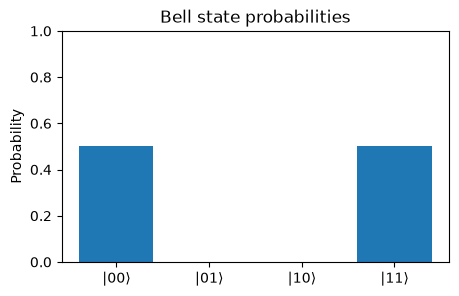

In [ ]:
# Bell-state construction

state_00 = basis_state("00")

H_on_first = apply_one_qubit_gate(H, n=2, target=0)
CNOT_01 = cnot(n=2, control=0, target=1)

after_H = H_on_first @ state_00
after_CNOT = CNOT_01 @ after_H

print("Initial |00⟩:")
print_state(state_00, basis_labels(2))

print("\nAfter H on first qubit:")
print_state(after_H, basis_labels(2))

print("\nAfter CNOT:")
print_state(after_CNOT, basis_labels(2))
show_probabilities(after_CNOT, basis_labels(2), "Bell state probabilities")

## 3. Interactive Bell-state builder

This cell lets you choose the first one-qubit gate and then optionally apply CNOT.

The important lesson:

- \(H\) creates superposition.
- CNOT can spread that superposition into two-qubit correlation.
- \(H\) followed by CNOT on \(|00\rangle\) creates an entangled Bell state.

Start: |00⟩
Apply H on first qubit
Apply CNOT: True

|00⟩: 0.707
|11⟩: 0.707
probabilities: [0.5 0.  0.  0.5]
total probability: 1.0


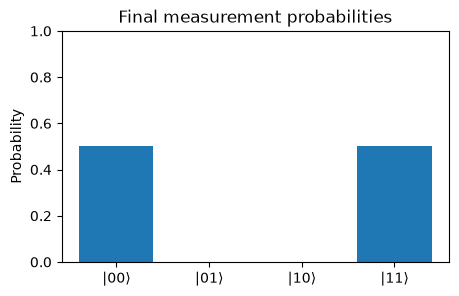

In [ ]:
def bell_builder(first_gate="H", apply_cnot=True):
    state = basis_state("00")
    G1 = apply_one_qubit_gate(ONE_QUBIT_GATES[first_gate], n=2, target=0)
    state_after_first = G1 @ state

    if apply_cnot:
        final_state = CNOT_01 @ state_after_first
    else:
        final_state = state_after_first

    print("Start: |00⟩")
    print(f"Apply {first_gate} on first qubit")
    print(f"Apply CNOT: {apply_cnot}")
    print()
    print_state(final_state, basis_labels(2))
    show_probabilities(final_state, basis_labels(2), "Final measurement probabilities")

if WIDGETS_AVAILABLE:
    interact(
        bell_builder,
        first_gate=widgets.Dropdown(options=["I", "X", "Z", "H", "S", "T"], value="H", description="first gate"),
        apply_cnot=widgets.Checkbox(value=True, description="apply CNOT"),
    )
else:
    bell_builder()

## 4. Why do we need to mirror a quantum circuit?

Quantum gates are **unitary**. That means they are reversible.

If a circuit is

$
C = G_k\cdots G_2G_1,
$

then the inverse circuit is

$
C^\dagger = G_1^\dagger G_2^\dagger \cdots G_k^\dagger.
$

In circuit-picture language, this is like a **mirror**:

1. reverse the order of the gates,
2. replace each gate by its inverse.

We need this because quantum computation is reversible at the gate level. Mirroring is used to **uncompute** temporary information.

For example, a circuit may compute some helper value into an ancilla qubit. Later we often need to clean that helper qubit back to \(|0\rangle\). We do that by running the computation backward.

Physically, this means: if the operation was a controlled physical evolution, the inverse operation reverses that evolution.

In [ ]:
# Example: make a circuit, then mirror it.

initial = basis_state("00")

circuit = [
    apply_one_qubit_gate(H, n=2, target=0),
    CNOT_01,
    apply_one_qubit_gate(T, n=2, target=1),
]

mirrored = inverse_circuit(circuit)

after_circuit = apply_circuit(initial, circuit)
after_mirror = apply_circuit(after_circuit, mirrored)

print("Initial state:")
print_state(initial, basis_labels(2))

print("\nAfter circuit:")
print_state(after_circuit, basis_labels(2))

print("\nAfter mirrored inverse circuit:")
print_state(after_mirror, basis_labels(2))

print("\nDid we return to the initial state?")
print(np.allclose(after_mirror, initial))

Initial state:
|00⟩: 1
probabilities: [1. 0. 0. 0.]
total probability: 1.0

After circuit:
|00⟩: 0.707
|11⟩: 0.5 + 0.5i
probabilities: [0.5 0.  0.  0.5]
total probability: 1.0

After mirrored inverse circuit:
|00⟩: 1
probabilities: [1. 0. 0. 0.]
total probability: 1.0

Did we return to the initial state?
True


## 5. Interactive mirror-circuit demo

Choose a short circuit. The notebook will apply it and then apply its mirror/inverse.

Even when the state becomes complicated in the middle, the mirror circuit brings it back.

In [ ]:
def named_gate_on_qubit(name, n, target):
    return apply_one_qubit_gate(ONE_QUBIT_GATES[name], n=n, target=target)

def mirror_demo(gate_a="H", gate_b="T", use_cnot=True):
    initial = basis_state("00")
    gates = [
        named_gate_on_qubit(gate_a, 2, 0),
        named_gate_on_qubit(gate_b, 2, 1),
    ]
    if use_cnot:
        gates.append(CNOT_01)

    forward = apply_circuit(initial, gates)
    backward = apply_circuit(forward, inverse_circuit(gates))

    print("Forward circuit:")
    print(f"{gate_a} on qubit 0, {gate_b} on qubit 1, CNOT={use_cnot}")
    print()
    print("After forward circuit:")
    print_state(forward, basis_labels(2))
    print()
    print("After mirror/inverse circuit:")
    print_state(backward, basis_labels(2))
    print("Returned to |00⟩:", np.allclose(backward, initial))

if WIDGETS_AVAILABLE:
    interact(
        mirror_demo,
        gate_a=widgets.Dropdown(options=["I", "X", "H", "S", "T"], value="H", description="gate A"),
        gate_b=widgets.Dropdown(options=["I", "X", "H", "S", "T"], value="T", description="gate B"),
        use_cnot=widgets.Checkbox(value=True, description="use CNOT"),
    )
else:
    mirror_demo()

Forward circuit:
H on qubit 0, T on qubit 1, CNOT=True

After forward circuit:
|00⟩: 0.707
|11⟩: 0.707
probabilities: [0.5 0.  0.  0.5]
total probability: 1.0

After mirror/inverse circuit:
|00⟩: 1
probabilities: [1. 0. 0. 0.]
total probability: 1.0
Returned to |00⟩: True


## 6. CNOT, CZ, and Hadamard identities

The chapter shows circuit identities involving CNOT, CZ, and \(H\).

One important identity is:

$
CZ = (I\otimes H)\,\mathrm{CNOT}\,(I\otimes H).
$

Meaning:

1. put \(H\) before and after the CNOT target,
2. the CNOT behaves like a controlled-\(Z\).

This is useful because it lets us transform one type of two-qubit interaction into another.

In [ ]:
I_on_first_H_on_second = apply_one_qubit_gate(H, n=2, target=1)
CZ_01 = cz(n=2, control=0, target=1)

constructed_CZ = I_on_first_H_on_second @ CNOT_01 @ I_on_first_H_on_second

print("Direct CZ:")
show_matrix(CZ_01, "CZ")

print("\nConstructed CZ = (I⊗H) CNOT (I⊗H):")
show_matrix(constructed_CZ, "constructed_CZ")

print("\nAre they equal?")
print(np.allclose(CZ_01, constructed_CZ))

Direct CZ:
CZ =
[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]]

Constructed CZ = (I⊗H) CNOT (I⊗H):
constructed_CZ =
[[ 1.+0.j -0.+0.j  0.+0.j  0.+0.j]
 [-0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j -0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]]

Are they equal?
True


## 7. Interactive CNOT/CZ/SWAP action

CNOT, CZ, and SWAP are basic two-qubit circuit operations.

- CNOT flips the target if the control is \(1\).
- CZ adds a phase \(-1\) to \(|11\rangle\).
- SWAP exchanges the two qubits.

CZ can look invisible in a probability plot because it changes phase, not the immediate \(0/1\) probabilities.

Gate: CNOT 0→1
Input: |10⟩

Output:
|11⟩: 1
probabilities: [0. 0. 0. 1.]
total probability: 1.0


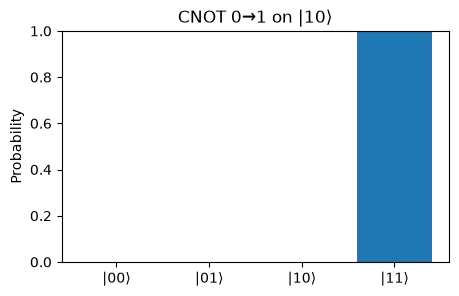

In [ ]:
TWO_QUBIT_GATES = {
    "CNOT 0→1": cnot(2, 0, 1),
    "CNOT 1→0": cnot(2, 1, 0),
    "CZ": cz(2, 0, 1),
    "SWAP": swap_gate(2, 0, 1),
}

def two_qubit_gate_demo(gate_name="CNOT 0→1", input_state="|10⟩"):
    U = TWO_QUBIT_GATES[gate_name]
    bitstring = input_state.replace("|", "").replace("⟩", "")
    state = basis_state(bitstring)
    out = U @ state

    print(f"Gate: {gate_name}")
    print(f"Input: {input_state}")
    print()
    print("Output:")
    print_state(out, basis_labels(2))
    show_probabilities(out, basis_labels(2), f"{gate_name} on {input_state}")

if WIDGETS_AVAILABLE:
    interact(
        two_qubit_gate_demo,
        gate_name=widgets.Dropdown(options=list(TWO_QUBIT_GATES.keys()), value="CNOT 0→1", description="gate"),
        input_state=widgets.Dropdown(options=["|00⟩", "|01⟩", "|10⟩", "|11⟩"], value="|10⟩", description="input"),
    )
else:
    two_qubit_gate_demo()

## 8. GHZ circuit

The chapter gives a compact notation for constructing GHZ states:

$
|GHZ_n\rangle =
\left(H_1 \circ \prod_{i=2}^{n}\mathrm{CNOT}_{1,i}\right)|0^n\rangle.
$

In simple words:

1. start with all qubits in \(|0\rangle\),
2. apply \(H\) to the first qubit,
3. CNOT from the first qubit into every other qubit.

This creates

$
|GHZ_n\rangle =
\frac{1}{\sqrt{2}}(|00\cdots0\rangle+|11\cdots1\rangle).
$

GHZ_3 built by circuit:
|000⟩: 0.707
|111⟩: 0.707
probabilities: [0.5 0.  0.  0.  0.  0.  0.  0.5]
total probability: 1.0


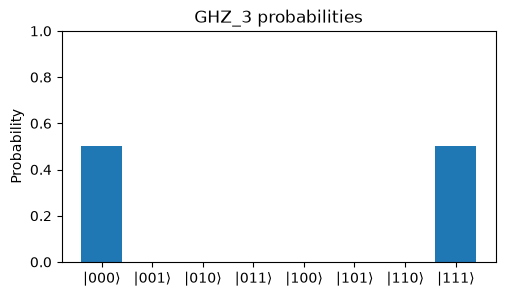


Matches direct GHZ state: True


In [ ]:
def ghz_by_circuit(n):
    state = basis_state("0"*n)
    state = apply_one_qubit_gate(H, n=n, target=0) @ state
    for target in range(1, n):
        state = cnot(n, control=0, target=target) @ state
    return state

def ghz_demo(n=3):
    state = ghz_by_circuit(n)
    print(f"GHZ_{n} built by circuit:")
    print_state(state, basis_labels(n))
    show_probabilities(state, basis_labels(n), f"GHZ_{n} probabilities")
    print("\nMatches direct GHZ state:", np.allclose(state, ghz_state(n)))

if WIDGETS_AVAILABLE:
    interact(
        ghz_demo,
        n=widgets.IntSlider(value=3, min=2, max=6, step=1, description="n"),
    )
else:
    ghz_demo()

## 9. Pauli operators on many qubits

The chapter introduces Pauli operators over several qubits, for example:

$
X\otimes Y\otimes Z.
$

This means:

- apply \(X\) to qubit 1,
- apply \(Y\) to qubit 2,
- apply \(Z\) to qubit 3.

These tensor-product Pauli operators are important because they describe many useful transformations and are central in Clifford circuits.

Operator: XYZ
Input: |010⟩

|100⟩: -1i
probabilities: [0. 0. 0. 0. 1. 0. 0. 0.]
total probability: 1.0


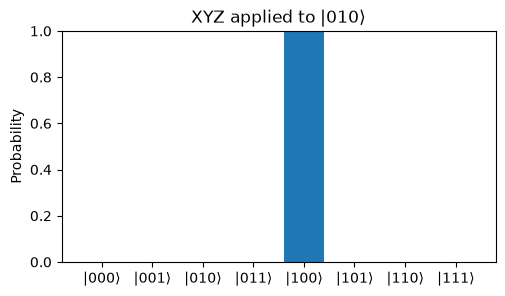

In [ ]:
PAULI_GATES = {
    "I": I,
    "X": X,
    "Y": Y,
    "Z": Z,
}

def pauli_operator(pauli_string):
    return kron(*[PAULI_GATES[ch] for ch in pauli_string])

def pauli_demo(pauli_string="XYZ", input_bitstring="010"):
    if len(pauli_string) != len(input_bitstring):
        print("Pauli string and bitstring must have the same length.")
        return

    U = pauli_operator(pauli_string)
    state = basis_state(input_bitstring)
    out = U @ state

    print(f"Operator: {pauli_string}")
    print(f"Input: |{input_bitstring}⟩")
    print()
    print_state(out, basis_labels(len(input_bitstring)))
    show_probabilities(out, basis_labels(len(input_bitstring)), f"{pauli_string} applied to |{input_bitstring}⟩")

if WIDGETS_AVAILABLE:
    interact(
        pauli_demo,
        pauli_string=widgets.Text(value="XYZ", description="Pauli"),
        input_bitstring=widgets.Text(value="010", description="Input"),
    )
else:
    pauli_demo()

## 10. Clifford conjugation: moving operators through gates

The chapter discusses moving Pauli operators through Clifford gates such as \(H\), \(S\), and CNOT.

Examples:

$
HXH = Z,
\qquad
HZH = X.
$

This means a Hadamard gate swaps the \(X\)-axis and \(Z\)-axis.

Also:

$
SXS^\dagger = Y.
$

These identities are useful because they let us simplify quantum circuits without multiplying huge matrices every time.

In [ ]:
def identify_pauli(U, tol=1e-8):
    candidates = {
        "I": I,
        "X": X,
        "Y": Y,
        "Z": Z,
        "-I": -I,
        "-X": -X,
        "-Y": -Y,
        "-Z": -Z,
    }
    for name, M in candidates.items():
        if np.allclose(U, M, atol=tol):
            return name
    for name, M in candidates.items():
        if np.allclose(U, 1j*M, atol=tol):
            return "i" + name
        if np.allclose(U, -1j*M, atol=tol):
            return "-i" + name
    return "not a simple Pauli"

def conjugation_demo(clifford="H", pauli="X"):
    C = ONE_QUBIT_GATES[clifford]
    P = PAULI_GATES[pauli]
    result = C @ P @ C.conj().T

    print(f"{clifford} {pauli} {clifford}† =")
    show_matrix(result, "result")
    print("Identified as:", identify_pauli(result))

if WIDGETS_AVAILABLE:
    interact(
        conjugation_demo,
        clifford=widgets.Dropdown(options=["H", "S"], value="H", description="Clifford"),
        pauli=widgets.Dropdown(options=["X", "Y", "Z"], value="X", description="Pauli"),
    )
else:
    conjugation_demo()

H X H† =
result =
[[ 1.+0.j -0.+0.j]
 [ 0.+0.j -1.+0.j]]
Identified as: Z


## 11. \(T\) gates and phase

The \(T\) gate is

$
T =
\begin{pmatrix}
1 & 0\\
0 & e^{i\pi/4}
\end{pmatrix}.
$

It adds a phase to the $|1\rangle$ part of the state.

On its own, this may not change measurement probabilities in the \(0/1\) basis. But after later gates, this phase can turn into observable interference.

This is why the chapter pays attention to \(T\) gates, \(T^\dagger\), and Clifford+\(T\) circuits.

Start with |+⟩:
|0⟩: 0.707
|1⟩: 0.707
probabilities: [0.5 0.5]
total probability: 1.0

After T:
|0⟩: 0.707
|1⟩: 0.5 + 0.5i
probabilities: [0.5 0.5]
total probability: 1.0


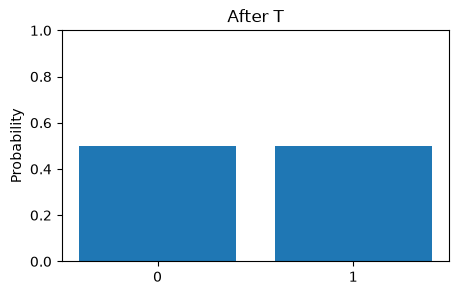


After H following T:
|0⟩: 0.854 + 0.354i
|1⟩: 0.146 - 0.354i
probabilities: [0.854 0.146]
total probability: 1.0


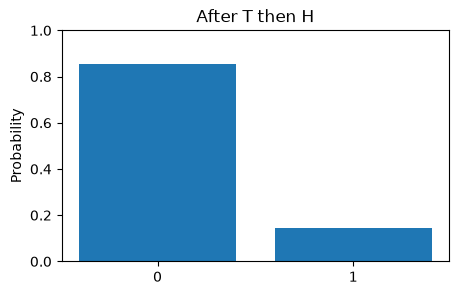

In [ ]:
def t_phase_demo(apply_final_H=True):
    state = ket_plus
    after_T = T @ state

    print("Start with |+⟩:")
    print_state(state, ["|0⟩", "|1⟩"])

    print("\nAfter T:")
    print_state(after_T, ["|0⟩", "|1⟩"])
    show_probabilities(after_T, ["0", "1"], "After T")

    if apply_final_H:
        final = H @ after_T
        print("\nAfter H following T:")
        print_state(final, ["|0⟩", "|1⟩"])
        show_probabilities(final, ["0", "1"], "After T then H")

if WIDGETS_AVAILABLE:
    interact(
        t_phase_demo,
        apply_final_H=widgets.Checkbox(value=True, description="apply final H"),
    )
else:
    t_phase_demo()

## 12. Phase-polynomial intuition

The chapter introduces phase-polynomial representations.

A diagonal quantum circuit often does this:

$
|x\rangle \mapsto e^{i f(x)}|x\rangle.
$

The bitstring $|x\rangle$ does not change. Only its phase changes.

CNOT gates can compute temporary XOR values such as

$
x_1\oplus x_2.
$

Then a phase gate such as \(T\), \(S\), or \(R_z\) can add phase depending on that computed value.

This is a useful way to understand circuits made from CNOT and phase gates.

In [ ]:
def phase_polynomial_toy(x1=0, x2=0):
    # Toy version of a CNOT + phase circuit:
    # compute x1 XOR x2, then add a T phase depending on x1 XOR x2.
    xor_value = x1 ^ x2
    phase = np.exp(1j * np.pi/4 * xor_value)

    print(f"x1 = {x1}, x2 = {x2}")
    print(f"x1 XOR x2 = {xor_value}")
    print(f"phase = exp(i*pi/4 * {xor_value}) = {pretty_complex(phase)}")
    print()
    print("Meaning:")
    print(f"|{x1}{x2}⟩ -> ({pretty_complex(phase)}) |{x1}{x2}⟩")

if WIDGETS_AVAILABLE:
    interact(
        phase_polynomial_toy,
        x1=widgets.Dropdown(options=[0, 1], value=0, description="x1"),
        x2=widgets.Dropdown(options=[0, 1], value=1, description="x2"),
    )
else:
    phase_polynomial_toy()

x1 = 0, x2 = 0
x1 XOR x2 = 0
phase = exp(i*pi/4 * 0) = 1

Meaning:
|00⟩ -> (1) |00⟩


## 13. Toffoli, CCZ, and quantum AND

The Toffoli gate, also called CCNOT, flips a target qubit if two control qubits are both \(1\).

$
|x_1,x_2,y\rangle
\mapsto
|x_1,x_2,y\oplus (x_1x_2)\rangle.
$

If the target starts in \(|0\rangle\), then the target becomes

$
|x_1x_2\rangle.
$

So Toffoli can compute classical AND reversibly.

The CCZ gate is related:

$
CCZ|x_1x_2x_3\rangle =
(-1)^{x_1x_2x_3}|x_1x_2x_3\rangle.
$

A Hadamard on the target converts between CCZ and Toffoli:

$
CCX = (I\otimes I\otimes H)\,CCZ\,(I\otimes I\otimes H).
$

Does H on target turn CCZ into Toffoli/CCX?
True
Input: |110⟩
After Toffoli CCX:
|111⟩: 1
probabilities: [0. 0. 0. 0. 0. 0. 0. 1.]
total probability: 1.0


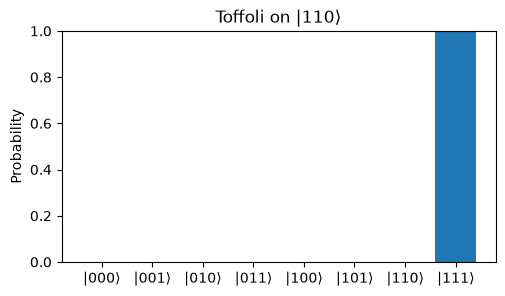

In [ ]:
CCX_012 = ccx(3, 0, 1, 2)
CCZ_012 = ccz(3, 0, 1, 2)
H_on_third = apply_one_qubit_gate(H, n=3, target=2)
CCX_from_CCZ = H_on_third @ CCZ_012 @ H_on_third

print("Does H on target turn CCZ into Toffoli/CCX?")
print(np.allclose(CCX_012, CCX_from_CCZ))

def toffoli_demo(input_bitstring="110"):
    state = basis_state(input_bitstring)
    out = CCX_012 @ state
    print(f"Input: |{input_bitstring}⟩")
    print("After Toffoli CCX:")
    print_state(out, basis_labels(3))
    show_probabilities(out, basis_labels(3), f"Toffoli on |{input_bitstring}⟩")

if WIDGETS_AVAILABLE:
    interact(
        toffoli_demo,
        input_bitstring=widgets.Dropdown(
            options=[f"{i:03b}" for i in range(8)],
            value="110",
            description="input",
        ),
    )
else:
    toffoli_demo()

## 14. Uniformly-controlled one-qubit gates

The chapter introduces uniformly-controlled one-qubit gates.

For one control qubit, this means:

$
|0\rangle|\phi\rangle \mapsto |0\rangle U_0|\phi\rangle
$

$
|1\rangle|\phi\rangle \mapsto |1\rangle U_1|\phi\rangle.
$

So the operation applied to the target depends on the classical value of the control basis state.

This generalizes controlled gates. CNOT is the special case:

$
U_0 = I,\qquad U_1 = X.
$

U0 = I, U1 = X
Input: |10⟩

|11⟩: 1
probabilities: [0. 0. 0. 1.]
total probability: 1.0


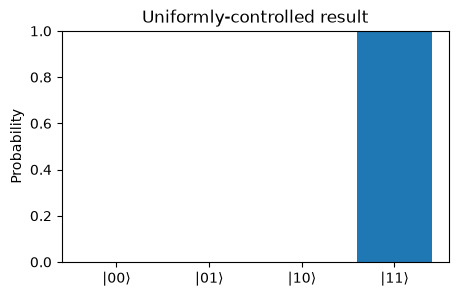

In [ ]:
def uniformly_controlled_one_qubit(U0, U1):
    return kron(np.outer(ket0, ket0.conj()), U0) + kron(np.outer(ket1, ket1.conj()), U1)

def uniformly_controlled_demo(U0_name="I", U1_name="X", input_state="|10⟩"):
    U0 = ONE_QUBIT_GATES[U0_name]
    U1 = ONE_QUBIT_GATES[U1_name]
    U = uniformly_controlled_one_qubit(U0, U1)

    bitstring = input_state.replace("|", "").replace("⟩", "")
    state = basis_state(bitstring)
    out = U @ state

    print(f"U0 = {U0_name}, U1 = {U1_name}")
    print(f"Input: {input_state}")
    print()
    print_state(out, basis_labels(2))
    show_probabilities(out, basis_labels(2), "Uniformly-controlled result")

if WIDGETS_AVAILABLE:
    interact(
        uniformly_controlled_demo,
        U0_name=widgets.Dropdown(options=["I", "X", "Z", "H", "S", "T"], value="I", description="U0"),
        U1_name=widgets.Dropdown(options=["I", "X", "Z", "H", "S", "T"], value="X", description="U1"),
        input_state=widgets.Dropdown(options=["|00⟩", "|01⟩", "|10⟩", "|11⟩"], value="|10⟩", description="input"),
    )
else:
    uniformly_controlled_demo()

# Seven simple follow-up exercises

These are intentionally simple. They are meant to help you check that the chapter ideas make sense.

You can edit the code cells and run them.

## Exercise 1 — Read a circuit as steps

The circuit idea is:

$
\mathrm{CNOT}(H\otimes I)|00\rangle.
$

In words:

1. start with \(|00\rangle\),
2. apply \(H\) to the first qubit,
3. apply CNOT.

Run the cell and observe the state after each step.

In [ ]:
# Exercise 1

state = basis_state("00")
print("Start:")
print_state(state, basis_labels(2))

state = apply_one_qubit_gate(H, 2, 0) @ state
print("\nAfter H on first qubit:")
print_state(state, basis_labels(2))

state = cnot(2, 0, 1) @ state
print("\nAfter CNOT:")
print_state(state, basis_labels(2))

Start:
|00⟩: 1
probabilities: [1. 0. 0. 0.]
total probability: 1.0

After H on first qubit:
|00⟩: 0.707
|10⟩: 0.707
probabilities: [0.5 0.  0.5 0. ]
total probability: 1.0

After CNOT:
|00⟩: 0.707
|11⟩: 0.707
probabilities: [0.5 0.  0.  0.5]
total probability: 1.0


## Exercise 2 — Change the first gate

Change `first_gate` to `"X"`, `"Z"`, or `"H"`.

Question: which choice creates a Bell state after CNOT?

First gate: H
|00⟩: 0.707
|11⟩: 0.707
probabilities: [0.5 0.  0.  0.5]
total probability: 1.0


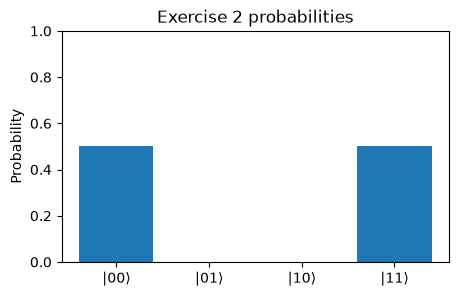

In [ ]:
# Exercise 2

first_gate = "H"

state = basis_state("00")
state = apply_one_qubit_gate(ONE_QUBIT_GATES[first_gate], 2, 0) @ state
state = cnot(2, 0, 1) @ state

print(f"First gate: {first_gate}")
print_state(state, basis_labels(2))
show_probabilities(state, basis_labels(2), "Exercise 2 probabilities")

## Exercise 3 — Mirror a circuit

A mirror circuit reverses a circuit.

Run the cell and check that the final state returns to \(|00\rangle\).

In [ ]:
# Exercise 3

state = basis_state("00")

circuit = [
    apply_one_qubit_gate(H, 2, 0),
    cnot(2, 0, 1),
    apply_one_qubit_gate(T, 2, 1),
]

forward_state = apply_circuit(state, circuit)
returned_state = apply_circuit(forward_state, inverse_circuit(circuit))

print("After forward circuit:")
print_state(forward_state, basis_labels(2))

print("\nAfter mirror/inverse:")
print_state(returned_state, basis_labels(2))

After forward circuit:
|00⟩: 0.707
|11⟩: 0.5 + 0.5i
probabilities: [0.5 0.  0.  0.5]
total probability: 1.0

After mirror/inverse:
|00⟩: 1
probabilities: [1. 0. 0. 0.]
total probability: 1.0


## Exercise 4 — Test CNOT inputs

Change `input_bitstring`.

Question: when does CNOT flip the second qubit?

In [ ]:
# Exercise 4

input_bitstring = "10"

state = basis_state(input_bitstring)
out = cnot(2, 0, 1) @ state

print(f"Input: |{input_bitstring}⟩")
print("Output:")
print_state(out, basis_labels(2))

Input: |10⟩
Output:
|11⟩: 1
probabilities: [0. 0. 0. 1.]
total probability: 1.0


## Exercise 5 — Build a small GHZ state

Change `n` between 2 and 5.

Question: which bitstrings have nonzero probability?

GHZ_3:
|000⟩: 0.707
|111⟩: 0.707
probabilities: [0.5 0.  0.  0.  0.  0.  0.  0.5]
total probability: 1.0


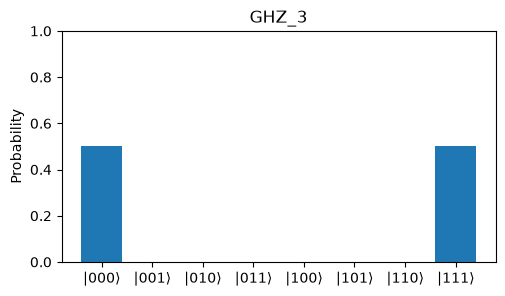

In [ ]:
# Exercise 5

n = 3

state = ghz_by_circuit(n)

print(f"GHZ_{n}:")
print_state(state, basis_labels(n))
show_probabilities(state, basis_labels(n), f"GHZ_{n}")

## Exercise 6 — Phase does not always change probabilities

Apply \(T\) to $|+\rangle$.

Then optionally apply \(H\) afterward.

Question: why does the phase become visible only after another gate?

In [ ]:
# Exercise 6

state = ket_plus

after_T = T @ state
after_T_then_H = H @ after_T

print("After T:")
print_state(after_T, ["|0⟩", "|1⟩"])

print("\nAfter T then H:")
print_state(after_T_then_H, ["|0⟩", "|1⟩"])

After T:
|0⟩: 0.707
|1⟩: 0.5 + 0.5i
probabilities: [0.5 0.5]
total probability: 1.0

After T then H:
|0⟩: 0.854 + 0.354i
|1⟩: 0.146 - 0.354i
probabilities: [0.854 0.146]
total probability: 1.0


## Exercise 7 — Toffoli as AND

The Toffoli gate computes AND into the target if the target starts as \(0\).

Try the inputs:

$
|000\rangle,\ |010\rangle,\ |100\rangle,\ |110\rangle.
$

Question: when does the target become \(1\)?

In [ ]:
# Exercise 7

input_bitstring = "000"

state = basis_state(input_bitstring)
out = ccx(3, 0, 1, 2) @ state

print(f"Input: |{input_bitstring}⟩")
print("After Toffoli:")
print_state(out, basis_labels(3))

Input: |110⟩
After Toffoli:
|111⟩: 1
probabilities: [0. 0. 0. 0. 0. 0. 0. 1.]
total probability: 1.0


# Summary on quantum gates

Quantum gates are operations that change the state of qubits.
Some gates change measurement probabilities directly, while others mainly change **phase**.

Phase changes can look invisible at first, but they become important when later gates cause **interference**.

---

### (X) gate

The (X) gate is the quantum version of a NOT gate.

It flips

$
\vert 0\rangle \mapsto \vert 1\rangle
$

and

$
\vert 1\rangle \mapsto \vert 0\rangle.
$

So it changes the computational value of a qubit.

---

### (Z) gate

The (Z) gate does not flip the qubit.
It changes the phase of the (\vert 1\rangle) state:

$
\vert 0\rangle \mapsto \vert 0\rangle
$

$
\vert 1\rangle \mapsto -\vert 1\rangle.
$

So (Z) is a phase gate.

For example,

$
Z\vert +\rangle = \vert -\rangle.
$

This matters because (\vert +\rangle) and (\vert -\rangle) have the same probabilities in the (0/1) basis, but behave differently after another gate such as (H).

---

### (H) gate

The Hadamard gate (H) creates and removes superposition.

It maps

$
H\vert 0\rangle = \vert +\rangle
$

and

$
H\vert 1\rangle = \vert -\rangle.
$

It also turns phase differences into measurable probability differences:

$
H\vert +\rangle = \vert 0\rangle
$

$
H\vert -\rangle = \vert 1\rangle.
$

So (H) is important because it connects **phase** and **measurement outcomes**.

---

### (S) gate

The (S) gate adds a phase of (i) to the (\vert 1\rangle) state:

$
S =
\begin{pmatrix}
1 & 0\
0 & i
\end{pmatrix}.
$

So

$
\vert 0\rangle \mapsto \vert 0\rangle
$

and

$
\vert 1\rangle \mapsto i\vert 1\rangle.
$

It is used to control phase more finely than the (Z) gate.

---

### (T) gate

The (T) gate adds a smaller phase to (\vert 1\rangle):

$
T =
\begin{pmatrix}
1 & 0\
0 & e^{i\pi/4}
\end{pmatrix}.
$

So it performs a smaller phase rotation than (S).

The (T) gate is important because many quantum circuits are built from **Clifford gates plus (T) gates**.
It helps create more general quantum transformations.

---

### CNOT gate

CNOT is a two-qubit gate.

It has:

* one control qubit,
* one target qubit.

It flips the target only when the control is (1).

$
\vert 00\rangle \mapsto \vert 00\rangle
$

$
\vert 01\rangle \mapsto \vert 01\rangle
$

$
\vert 10\rangle \mapsto \vert 11\rangle
$

$
\vert 11\rangle \mapsto \vert 10\rangle
$

CNOT is important because it can create entanglement.

For example,

$
\vert +\rangle\vert 0\rangle = \frac{1}{\sqrt{2}}(\vert 00\rangle+\vert 10\rangle)
$

becomes

$
\frac{1}{\sqrt{2}}(\vert 00\rangle+\vert 11\rangle)
$

after CNOT.

---

### CZ gate

CZ means controlled-(Z).

It adds a minus sign only to the (\vert 11\rangle) state:

$
CZ\vert 00\rangle = \vert 00\rangle
$

$
CZ\vert 01\rangle = \vert 01\rangle
$

$
CZ\vert 10\rangle = \vert 10\rangle
$

$
CZ\vert 11\rangle = -\vert 11\rangle.
$

So CZ does not flip bits.
It marks one state with a phase.

This is useful because later gates can turn that phase mark into a measurable difference.

---

### SWAP gate

The SWAP gate exchanges two qubits:

$
SWAP\vert a\rangle\vert b\rangle = \vert b\rangle\vert a\rangle.
$

For example,

$
SWAP\vert 01\rangle = \vert 10\rangle.
$

It is used when we need to move quantum information between qubit positions.

---

### Toffoli gate / CCNOT

The Toffoli gate is a controlled-controlled-NOT gate.

It flips the target qubit only when both controls are (1).

$
\vert x_1,x_2,y\rangle
\mapsto
\vert x_1,x_2,y\oplus(x_1x_2)\rangle.
$

If the target starts in (\vert 0\rangle), it computes AND:

$
\vert x_1,x_2,0\rangle
\mapsto
\vert x_1,x_2,x_1x_2\rangle.
$

So Toffoli is useful for reversible classical logic inside quantum circuits.

---

### CCZ gate

CCZ means controlled-controlled-(Z).

It adds a minus sign only to (\vert 111\rangle):

$
CCZ\vert 111\rangle = -\vert 111\rangle.
$

All other basis states stay the same.

So CCZ is like Toffoli, but instead of flipping a bit, it changes a phase.

Toffoli and CCZ are related by Hadamard gates:

$
CCX = (I\otimes I\otimes H),CCZ,(I\otimes I\otimes H).
$

This means a phase operation can be converted into a bit-flip operation by changing basis.

---

## Why phase manipulation helps

Phase manipulation is useful because quantum states behave like waves.

Waves can add together or cancel each other:

$
\text{same phase} \rightarrow \text{constructive interference}
$

$
\text{opposite phase} \rightarrow \text{destructive interference}
$

Quantum algorithms use this idea.

They often:

1. create a superposition,
2. add phases to mark important states,
3. apply more gates so amplitudes interfere,
4. increase the probability of measuring the desired answer.

A phase change may not be visible immediately in the measurement probabilities.
But after gates like (H), CNOT, or other transformations, the phase can turn into a real probability difference.

That is why gates like (Z), (S), (T), CZ, and CCZ are important: they control interference.
